# Phân tích Sức khỏe Thể chất (Physical Health EDA)

**Mục tiêu của Notebook này:**
1. Khám phá các rắc rối thể chất phổ biến nhất mà nhân viên gặp phải (Đau lưng, mỏi mắt, v.v.).
2. Phân tích tác động của môi trường làm việc (Remote, Hybrid, Onsite) lên sức khỏe thể chất.
3. Nhận diện các ngành nghề (Industry) có nguy cơ rủi ro thể chất cao nhất.

In [12]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [13]:
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [14]:
df = load_raw_data()
df_clean = get_da_data(df)
df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K


## 1. Tổng quan: Căn bệnh văn phòng nào đang "thống trị"?
Chúng ta sẽ xem xét tần suất xuất hiện của các triệu chứng thể chất. Đoạn code dưới đây sẽ tự động xử lý cả trường hợp mỗi người có 1 bệnh, hoặc 1 người có nhiều bệnh ngăn cách nhau bởi dấu phẩy.

In [31]:
disease_cols = ['has_Back Pain', 'has_Eye Strain', 'has_Neck Pain', 'has_Shoulder Pain', 'has_Wrist Pain'] 
disease_counts = df_clean[disease_cols].sum().sort_values(ascending=False)

C:\Users\HPC\AppData\Local\Temp\ipykernel_8520\3815702887.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='Reds_r')


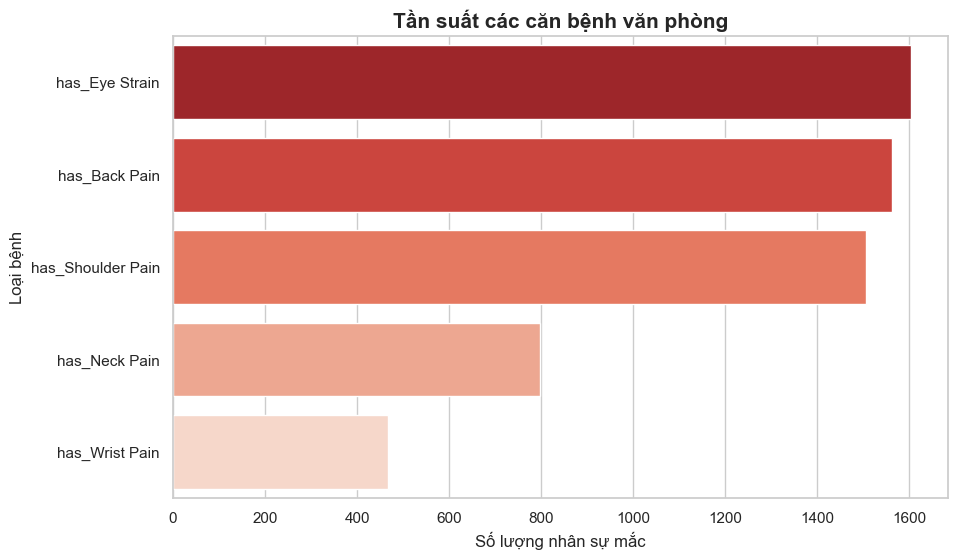

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='Reds_r')
plt.title('Tần suất các căn bệnh văn phòng', fontsize=15, fontweight='bold')
plt.xlabel('Số lượng nhân sự mắc')
plt.ylabel('Loại bệnh')
plt.show()

**Nhận xét:**
* Mỏi mắt dẫn đầu với ~1.600 người — đây là hệ quả trực tiếp của việc nhìn màn hình kéo dài, chiếu sáng kém và ít nghỉ ngơi mắt.
* Bộ ba Eye Strain – Back Pain – Shoulder Pain có số liệu rất gần nhau (~1.500–1.600), cho thấy đây là nhóm bệnh đặc trưng và gần như không thể tách rời của môi trường làm việc văn phòng, liên quan mật thiết đến tư thế ngồi và sử dụng màn hình.
* Neck Pain và Wrist Pain thấp hơn hẳn, tạo ra khoảng cách rõ rệt so với nhóm trên. Wrist Pain (~480) chỉ bằng khoảng 30% so với Eye Strain — có thể do ít người nhận thức được hoặc triệu chứng chưa nghiêm trọng đến mức báo cáo.

## 2. Phân tích "Bệnh lý đi kèm" (Co-occurrence Analysis)
Trong y tế và sức khỏe nghề nghiệp, các bệnh lý hiếm khi xuất hiện đơn lẻ mà thường đi kèm thành "hội chứng" (ví dụ: ngồi sai tư thế vừa gây đau lưng vừa gây đau cổ). Chúng ta sẽ sử dụng Ma trận tương quan (Correlation Matrix) để xem các bệnh lý nào thường xuyên xuất hiện cùng nhau nhất.

In [30]:
corr_matrix = df_clean[disease_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

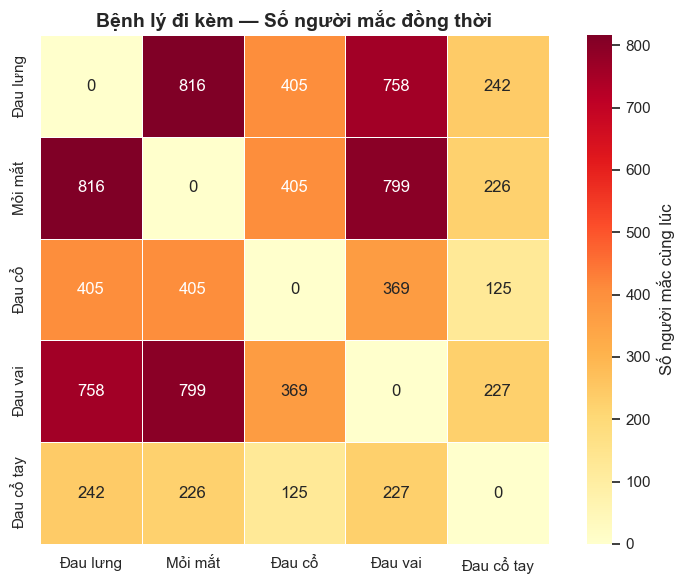

In [36]:

label_map = {
    'has_Back Pain'     : 'Đau lưng',
    'has_Eye Strain'    : 'Mỏi mắt',
    'has_Neck Pain'     : 'Đau cổ',
    'has_Shoulder Pain' : 'Đau vai',
    'has_Wrist Pain'    : 'Đau cổ tay'
}

df_disease = df_clean[disease_cols].rename(columns=label_map)

# Tính co-occurrence
cooc = df_disease.T.dot(df_disease)
cooc_values = cooc.values.copy()     
np.fill_diagonal(cooc_values, 0)
cooc = pd.DataFrame(cooc_values, index=cooc.index, columns=cooc.columns)

# Vẽ
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooc, annot=True, fmt='g', cmap='YlOrRd',
            linewidths=0.5, ax=ax, square=True,
            cbar_kws={"label": "Số người mắc cùng lúc"})

plt.title('Bệnh lý đi kèm — Số người mắc đồng thời',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét (Observation):**
* Nhóm liên kết chặt — "Tam giác bệnh lý cốt lõi"

    * Đau lưng – Mỏi mắt – Đau vai tạo thành nhóm 3 bệnh có tương quan cao nhất, với số người mắc đồng thời dao động 758–816 người.


    * Đây không phải ngẫu nhiên: cả 3 đều bắt nguồn từ tư thế ngồi sai + nhìn màn hình kéo dài, tạo ra vòng lặp bệnh lý lẫn nhau.
Người bị đau lưng thường cong vai → gây đau vai; cúi đầu nhìn màn hình → gây mỏi mắt.

* Nhóm liên kết trung bình

    * Đau cổ đi kèm với đau lưng và mỏi mắt ở mức 405 người — cho thấy đây là bệnh thứ phát, xuất hiện khi các bệnh cốt lõi đã có.
    * Đau cổ – Đau vai (369) cũng hợp lý vì cổ và vai cùng nhóm cơ, thường bị ảnh hưởng đồng thời.

* Đau cổ tay — bệnh lý độc lập nhất

    * Đau cổ tay có số đồng mắc thấp nhất với tất cả các bệnh còn lại (125–242).
Điều này cho thấy đau cổ tay có nguyên nhân riêng biệt (gõ phím, chuột nhiều) và ít liên quan đến tư thế toàn thân hơn.

## 3. Chỉ số Rủi ro Thể chất (Total Physical Issues) theo Môi trường và Ngành nghề
Thay vì nhìn vào từng bệnh, ta sẽ gom nhóm lại xem một nhân sự đang phải gánh chịu trung bình bao nhiêu rủi ro thể chất cùng lúc. Điều này giúp đánh giá tổng quan xem làm việc Remote, Hybrid hay Onsite đang bào mòn sức khỏe nhiều hơn.

C:\Users\HPC\AppData\Local\Temp\ipykernel_8520\791681778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Work_Arrangement', y='Physical_Issues_Count', ax=axes[0], palette='Set2')
C:\Users\HPC\AppData\Local\Temp\ipykernel_8520\791681778.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, y='Industry', x='Physical_Issues_Count', ax=axes[1], palette='viridis', errorbar=None)


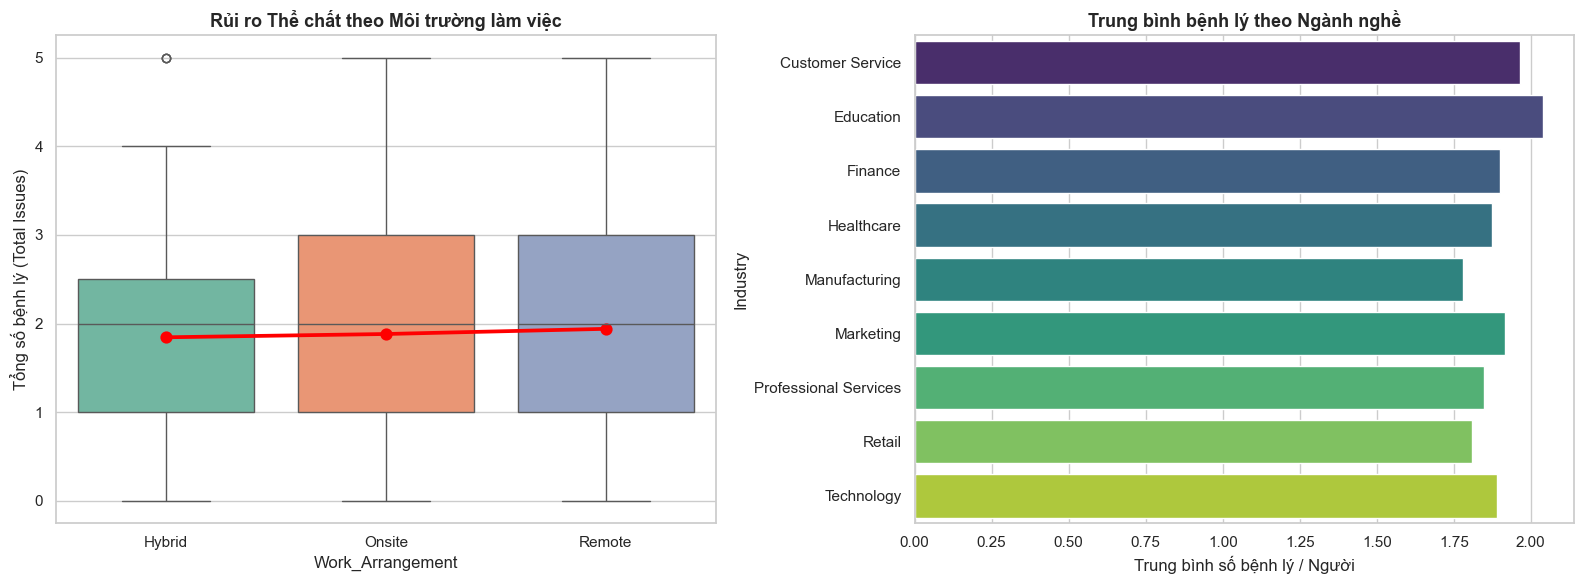

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Môi trường làm việc 
sns.boxplot(data=df_clean, x='Work_Arrangement', y='Physical_Issues_Count', ax=axes[0], palette='Set2')
sns.pointplot(data=df_clean, x='Work_Arrangement', y='Physical_Issues_Count', ax=axes[0], color='red', errorbar=None)
axes[0].set_title('Rủi ro Thể chất theo Môi trường làm việc', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tổng số bệnh lý (Total Issues)')

# Biểu đồ 2: Ngành nghề (Industry)
sns.barplot(data=df_clean, y='Industry', x='Physical_Issues_Count', ax=axes[1], palette='viridis', errorbar=None)
axes[1].set_title('Trung bình bệnh lý theo Ngành nghề', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Trung bình số bệnh lý / Người')

plt.tight_layout()
plt.show()

**Nhận xét (Observation):**
* Biểu đồ trái — Box Plot: Rủi ro Thể chất theo Môi trường làm việc
    Ba hình thức làm việc có trung vị (median) bằng nhau = 2 bệnh/người (đường đỏ nằm ngang), cho thấy hình thức làm việc không ảnh hưởng đến số bệnh trung bình.
    * Onsite có outlier ~5 bệnh/người — tồn tại nhóm nhân sự chịu rủi ro thể chất rất cao khi làm việc trực tiếp.
    * Remote có phân phối lệch dương (Q1 cao hơn) → người làm remote ít có trường hợp ít bệnh, ít được "bảo vệ" hơn so với kỳ vọng.
    * Hybrid có phân tán nhỏ nhất → rủi ro ổn định và thấp hơn ở nhóm ngoài trung vị.
* Biểu đồ phải — Bar Chart: Trung bình bệnh lý theo Ngành nghề
    Tất cả các ngành đều dao động trong khoảng 1.75 – 2.00 bệnh/người, biên độ chênh lệch khá nhỏ (~0.25), cho thấy rủi ro thể chất phân bổ tương đối đồng đều giữa các ngành.
    * Customer Service & Education dẫn đầu rủi ro — đây là các ngành đòi hỏi giao tiếp nhiều, ngồi lâu, áp lực tinh thần cao song hành với thể chất.
    * Technology thấp nhất — có thể do nhận thức tốt hơn về ergonomics, làm việc linh hoạt hơn (đã thấy ở biểu đồ trước: Hybrid/Remote cao).
    * Khoảng cách giữa các ngành không lớn, gợi ý rằng bệnh văn phòng là vấn đề phổ quát, không phân biệt ngành nghề nhiều.

## 4. Phân tích Chuyên sâu (Advanced): Ảnh hưởng của Cường độ làm việc đến Đau mắt
Chúng ta sẽ sử dụng phương pháp phân tích Logistic hồi quy trực quan để xem tỷ lệ (xác suất) mắc bệnh Đau lưng (Back Pain) tăng lên như thế nào khi số giờ làm việc trong tuần tăng lên.

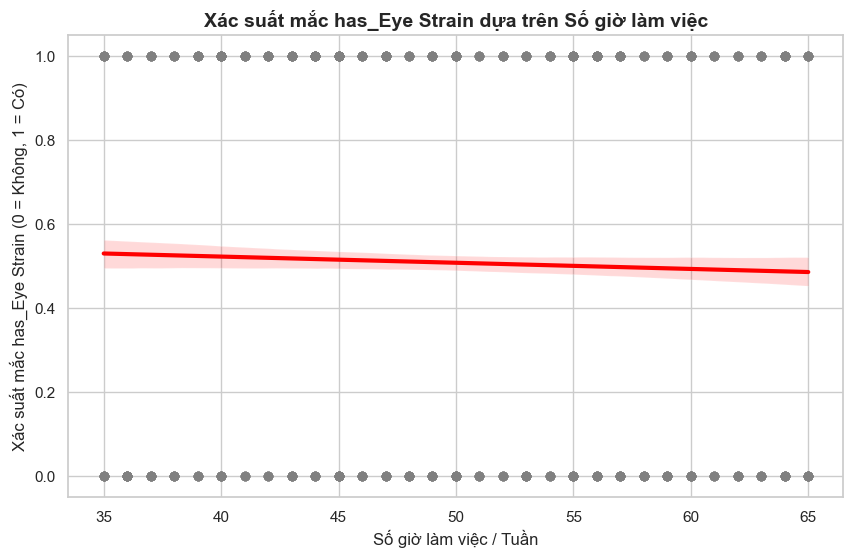

In [ ]:
col_hours = 'Hours_Per_Week'
col_target_disease = 'has_Eye Strain' 

plt.figure(figsize=(10, 6))

# Vẽ đường hồi quy Logistic (đánh giá xác suất mắc bệnh 1/0)
sns.regplot(data=df_clean, x=col_hours, y=col_target_disease, ci=95, 
            scatter_kws={'alpha':0.1, 'color':'gray'}, 
            line_kws={'color':'red', 'linewidth': 3})

plt.title(f'Xác suất mắc {col_target_disease} dựa trên Số giờ làm việc', fontsize=14, fontweight='bold')
plt.xlabel('Số giờ làm việc / Tuần')
plt.ylabel(f'Xác suất mắc {col_target_disease} (0 = Không, 1 = Có)')
plt.ylim(-0.05, 1.05)
plt.show()

**Nhận xét:** Đường hồi quy màu đỏ thể hiện xu hướng rõ rệt: Khi số giờ làm việc tăng lên, khả năng mắc bệnh Eye Strain giảm xuống, thể hiện khả năng thích nghi của người làm việc trong môi trường của họ, ường độ làm việc càng cao thì khả năng chịu đựng càng tăng. 